Competition description

Twitter has become an important communication channel in times of emergency.
The ubiquitousness of smartphones enables people to announce an emergency they’re observing in real-time. Because of this, more agencies are interested in programatically monitoring Twitter (i.e. disaster relief organizations and news agencies).

But, it’s not always clear whether a person’s words are actually announcing a disaster.

Acknowledgments

This dataset was created by the company figure-eight and originally shared on their ‘Data For Everyone’ website here.

Import libraries

In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns
import warnings 
warnings.filterwarnings("ignore", category=DeprecationWarning)

Loads train, test, and sample files

In [2]:
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/nlp-getting-started/sample_submission.csv
/kaggle/input/nlp-getting-started/train.csv
/kaggle/input/nlp-getting-started/test.csv


Read

In [3]:
train  = pd.read_csv('/kaggle/input/nlp-getting-started/train.csv')
test = pd.read_csv('/kaggle/input/nlp-getting-started/test.csv')
submission = pd.read_csv('/kaggle/input/nlp-getting-started/sample_submission.csv')

In [4]:
train

,id,keyword,location,text,target
0,1,NaN,NaN,Our Deeds are the Reason of this #earthquake M...,1
1,4,NaN,NaN,Forest fire near La Ronge Sask. Canada,1
2,5,NaN,NaN,All residents asked to 'shelter in place' are ...,1
3,6,NaN,NaN,"13,000 people receive #wildfires evacuation or...",1
4,7,NaN,NaN,Just got sent this photo from Ruby #Alaska as ...,1
...,...,...,...,...,...
7608,10869,NaN,NaN,Two giant cranes holding a bridge collapse int...,1
7609,10870,NaN,NaN,@aria_ahrary @TheTawniest The out of control w...,1
7610,10871,NaN,NaN,M1.94 [01:04 UTC]?5km S of Volcano Hawaii. htt...,1
7611,10872,NaN,NaN,Police investigating after an e-bike collided ...,1


In [5]:
test

,id,keyword,location,text
0,0,NaN,NaN,Just happened a terrible car crash
1,2,NaN,NaN,"Heard about #earthquake is different cities, s..."
2,3,NaN,NaN,"there is a forest fire at spot pond, geese are..."
3,9,NaN,NaN,Apocalypse lighting. #Spokane #wildfires
4,11,NaN,NaN,Typhoon Soudelor kills 28 in China and Taiwan
...,...,...,...,...
3258,10861,NaN,NaN,EARTHQUAKE SAFETY LOS ANGELES ÛÒ SAFETY FASTE...
3259,10865,NaN,NaN,Storm in RI worse than last hurricane. My city...
3260,10868,NaN,NaN,Green Line derailment in Chicago http://t.co/U...
3261,10874,NaN,NaN,MEG issues Hazardous Weather Outlook (HWO) htt...


In [6]:
submission

,id,target
0,0,0
1,2,0
2,3,0
3,9,0
4,11,0
...,...,...
3258,10861,0
3259,10865,0
3260,10868,0
3261,10874,0


Combine train and test

In [7]:
target = train.target
train.drop('target', axis=1, inplace=True)
train

,id,keyword,location,text
0,1,NaN,NaN,Our Deeds are the Reason of this #earthquake M...
1,4,NaN,NaN,Forest fire near La Ronge Sask. Canada
2,5,NaN,NaN,All residents asked to 'shelter in place' are ...
3,6,NaN,NaN,"13,000 people receive #wildfires evacuation or..."
4,7,NaN,NaN,Just got sent this photo from Ruby #Alaska as ...
...,...,...,...,...
7608,10869,NaN,NaN,Two giant cranes holding a bridge collapse int...
7609,10870,NaN,NaN,@aria_ahrary @TheTawniest The out of control w...
7610,10871,NaN,NaN,M1.94 [01:04 UTC]?5km S of Volcano Hawaii. htt...
7611,10872,NaN,NaN,Police investigating after an e-bike collided ...


In [8]:
combi = train.append(test)
combi

,id,keyword,location,text
0,1,NaN,NaN,Our Deeds are the Reason of this #earthquake M...
1,4,NaN,NaN,Forest fire near La Ronge Sask. Canada
2,5,NaN,NaN,All residents asked to 'shelter in place' are ...
3,6,NaN,NaN,"13,000 people receive #wildfires evacuation or..."
4,7,NaN,NaN,Just got sent this photo from Ruby #Alaska as ...
...,...,...,...,...
3258,10861,NaN,NaN,EARTHQUAKE SAFETY LOS ANGELES ÛÒ SAFETY FASTE...
3259,10865,NaN,NaN,Storm in RI worse than last hurricane. My city...
3260,10868,NaN,NaN,Green Line derailment in Chicago http://t.co/U...
3261,10874,NaN,NaN,MEG issues Hazardous Weather Outlook (HWO) htt...


Impute any null values

In [9]:
combi.isnull().sum()

id             0
keyword       87
location    3638
text           0
dtype: int64

In [10]:
# substitue NaN value here with mode

combi['location'] = combi['location'].fillna("not listed")
combi['keyword'] = combi['keyword'].fillna("not listed")

In [11]:
combi.isnull().sum()

id          0
keyword     0
location    0
text        0
dtype: int64

Compare tweets in train and test file

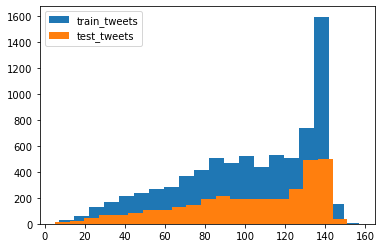

In [12]:
#compare tweets in train and test file
length_train=train['text'].str.len()
length_test=test['text'].str.len()
plt.hist(length_train, bins=20, label="train_tweets")
plt.hist(length_test, bins=20, label="test_tweets")
plt.legend()
plt.show()

Identify percentage of disaster tweets

In [13]:
target.value_counts()

0    4342
1    3271
Name: target, dtype: int64

In [14]:
percentage_disaster=(target.value_counts() / len(train)) * 100
percentage_disaster

0    57.034021
1    42.965979
Name: target, dtype: float64

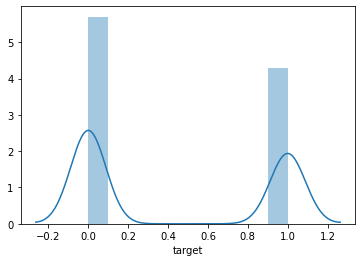

In [15]:
sns.distplot(target)

Preprocessing raw text and getting it ready for machine learning

In [16]:
import re
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords
from nltk.stem.snowball import SnowballStemmer

stemmer = SnowballStemmer(language='english')
words = stopwords.words("english")

tweets = combi['text'].apply(lambda x: " ".join([stemmer.stem(i) 
for i in re.sub("[^a-zA-Z]", " ", x).split() if i not in words]).lower())

print(len(words))

[nltk_data] Error loading stopwords: <urlopen error [Errno -3]
[nltk_data]     Temporary failure in name resolution>
179


In [17]:
#make all words lower case
tweets = tweets.str.lower()

#Remove punctuation
tweets = tweets.str.replace(r'[^\w\s]+', '')

# remove hash tags
tweets = tweets.str.replace("#", " ")

#remove words less than 2 character
tweets = tweets.apply(lambda x: ' '.join([w for w in x.split() if len(w)>2]))

Remove rare words

In [18]:
from collections import Counter
from itertools import chain

# split words into lists
v = tweets.str.split().tolist() 
# compute global word frequency
c = Counter(chain.from_iterable(v))
# filter, join, and re-assign
tweets = [' '.join([j for j in i if c[j] > 1]) for i in v]

Define X, y and X_test

In [19]:
#define x, y and t_test
y = target
X = np.array(tweets[: len(train)])
X_test = np.array(tweets[len(train) :])
X.shape, X_test.shape, y.shape

((7613,), (3263,), (7613,))

Split train set for training and testing

In [20]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(X, y, stratify=y, test_size=0.10, random_state=42, shuffle=True)
X_train.shape, X_val.shape, y_train.shape,y_val.shape, X_test.shape

((6851,), (762,), (6851,), (762,), (3263,))

Converting Text to Word Frequency Vectors with TfidfVectorizer

In [21]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer_tfidf = TfidfVectorizer(stop_words='english', max_df=0.5, min_df=0.01)

X_train = np.array(X_train).tolist()
X_train = list(map(''.join, X_train))

X_val = np.array(X_val).tolist()
X_val = list(map(''.join, X_val))

X_test = np.array(X_test).tolist()
X_test = list(map(''.join, X_test))


X_train_tfIdf = vectorizer_tfidf.fit_transform(X_train).toarray()
X_val_tfIdf = vectorizer_tfidf.transform(X_val).toarray()
X_test_tfIdf = vectorizer_tfidf.transform(X_test).toarray()
print(vectorizer_tfidf.get_feature_names()[:5])

['accid', 'amp', 'attack', 'bag', 'bodi']


In [22]:
X_train_tfIdf.shape, y_train.shape, X_val_tfIdf.shape,y_train.shape, X_test_tfIdf.shape

((6851, 94), (6851,), (762, 94), (6851,), (3263, 94))

In [23]:
feature_len = X_train_tfIdf.shape[1]
feature_len

94

Define and train the model

In [24]:
import tensorflow as tf
from tensorflow import keras
from keras.models import Sequential
from tensorflow.keras.layers import Dense
print(tf.__version__)

2.3.0


In [25]:
# create model
model = Sequential()
model.add(Dense(500, input_shape=(feature_len,), activation='relu'))
model.add(Dense(100, input_shape=(feature_len,), activation='relu'))
model.add(Dense(1, activation='sigmoid'))
 # Compile model
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
print(model.summary())

Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
dense (Dense)                (None, 500)               47500     
_________________________________________________________________
dense_1 (Dense)              (None, 100)               50100     
_________________________________________________________________
dense_2 (Dense)              (None, 1)                 101       
Total params: 97,701
Trainable params: 97,701
Non-trainable params: 0
_________________________________________________________________
None


In [26]:
model.compile(loss='binary_crossentropy', 
             optimizer='adam', 
             metrics=['accuracy'])

In [27]:
batch_size = 32

model.fit(X_train_tfIdf, y_train, epochs = 50, batch_size=batch_size, verbose=1, shuffle=False)
validation_loss, validation_acc = model.evaluate(X_val_tfIdf, y_val)

Epoch 1/50
215/215 [==============================] - 0s 2ms/step - loss: 0.5851 - accuracy: 0.6900
Epoch 2/50
215/215 [==============================] - 0s 2ms/step - loss: 0.5367 - accuracy: 0.7287
Epoch 3/50
215/215 [==============================] - 0s 2ms/step - loss: 0.5219 - accuracy: 0.7387
Epoch 4/50
215/215 [==============================] - 1s 3ms/step - loss: 0.5096 - accuracy: 0.7470
Epoch 5/50
215/215 [==============================] - 1s 3ms/step - loss: 0.4982 - accuracy: 0.7549
Epoch 6/50
215/215 [==============================] - 0s 2ms/step - loss: 0.4865 - accuracy: 0.7590
Epoch 7/50
215/215 [==============================] - 0s 2ms/step - loss: 0.4740 - accuracy: 0.7666
Epoch 8/50
215/215 [==============================] - 0s 2ms/step - loss: 0.4619 - accuracy: 0.7751
Epoch 9/50
215/215 [==============================] - 0s 2ms/step - loss: 0.4506 - accuracy: 0.7806
Epoch 10/50
215/215 [==============================] - 0s 2ms/step - loss: 0.4406 - accuracy: 0.7848

Predict on validation set

In [28]:
y_pred = model.predict(X_val_tfIdf)
y_pred = y_pred.flatten()
y_pred

array([7.48332858e-01, 4.32334900e-01, 3.39832418e-02, 4.32334900e-01,
       9.88222063e-01, 6.69877827e-02, 4.32334900e-01, 3.76941860e-02,
       5.63064916e-03, 1.28073590e-02, 1.61921725e-01, 1.93517938e-01,
       9.96118546e-01, 1.61921725e-01, 9.99999404e-01, 6.93347454e-01,
       6.60910070e-01, 9.99992132e-01, 9.99659300e-01, 6.94322467e-01,
       9.99915719e-01, 4.32334900e-01, 4.61895794e-01, 3.87836248e-01,
       9.90401804e-01, 1.74592122e-01, 4.32334900e-01, 1.44436012e-03,
       4.30222929e-01, 5.37502527e-01, 2.77067244e-01, 1.35444509e-06,
       9.93434072e-01, 4.13371682e-01, 4.32334900e-01, 4.98246104e-02,
       9.99974132e-01, 7.72977397e-02, 3.87786627e-01, 4.07200933e-01,
       1.49065517e-02, 9.99979496e-01, 4.32334900e-01, 4.32334900e-01,
       9.99997973e-01, 4.32334900e-01, 9.16911840e-01, 1.16341904e-01,
       1.61921725e-01, 2.21286580e-01, 9.15652275e-01, 2.37531140e-01,
       4.08597436e-04, 1.50066540e-01, 9.39586103e-01, 3.31853330e-01,
      

In [29]:
print('Min: ',y_pred.min())
print('Max: ',y_pred.max())
print('Mean: ',y_pred.mean())

Min:  1.3544451e-06
Max:  1.0
Mean:  0.41860032


In [30]:
cutoff = y_pred.max() / 2

y_pred = np.where(y_pred > cutoff, 1, 0)
y_pred

array([1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0,
       0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0,
       1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 1,
       0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 1, 0, 1, 1,
       0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1,
       0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1,
       1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       1, 0, 1, 0, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1, 1, 0, 0, 0, 1, 0,
       0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0,
       0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0,
       0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0,

In [31]:
print('Validation accuracy:', validation_acc)

Validation accuracy: 0.6994750499725342


In [32]:
from sklearn.metrics import confusion_matrix

print(confusion_matrix(y_val, y_pred.ravel()))

[[366  69]
 [160 167]]


In [33]:
df=pd.DataFrame({'Actual': y_val, 'Predicted':y_pred.ravel()})
df

,Actual,Predicted
1224,0,1
7007,0,0
6490,0,0
5337,0,0
38,1,1
...,...,...
5114,1,1
6306,0,0
5605,1,1
896,0,0


Predict on test set

In [34]:
test_pred = model.predict(X_test_tfIdf)
test_pred = test_pred.flatten()
test_pred

array([0.99982256, 0.16192172, 0.16192172, ..., 0.58416015, 0.5678457 ,
       0.9998909 ], dtype=float32)

In [35]:
print('Min: ',test_pred.min())
print('Max: ',test_pred.max())
print('Mean: ',test_pred.mean())

Min:  1.4425375e-07
Max:  1.0
Mean:  0.4129913


In [36]:
cutoff = test_pred.max() / 2

test_pred = np.where(test_pred > cutoff, 1, 0)
test_pred

array([1, 0, 0, ..., 1, 1, 1])

Submission

In [37]:
submission['target'] = test_pred
submission.to_csv('submission.csv',index=False) # writing data to a CSV file
submission = pd.read_csv("submission.csv")
submission

,id,target
0,0,1
1,2,0
2,3,0
3,9,1
4,11,0
...,...,...
3258,10861,0
3259,10865,1
3260,10868,1
3261,10874,1
